In [26]:
import kagglehub
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")


In [27]:
import pandas as pd
import os
import numpy as np

In [28]:
print(path)
print(os.listdir(path))

C:\Users\USER\.cache\kagglehub\datasets\ahmedmohamed2003\cafe-sales-dirty-data-for-cleaning-training\versions\1
['dirty_cafe_sales.csv']


In [29]:
df = pd.read_csv(path + "/dirty_cafe_sales.csv")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [31]:
df.shape

(10000, 8)

In [32]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [33]:
print(df['Item'].unique())
print(df['Location'].unique())
print(df['Payment Method'].unique())

['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]


Pengecekan Sebelum Cleaning

1. Standarosasi Missing Value

In [34]:
df.replace(['ERROR', 'UNKNOWN'], np.nan, inplace=True)

2. Evaluasi Persentase Missing 

In [39]:
(df.isnull().sum() / len(df)) * 100

Transaction ID       0.00
Item                 9.69
Quantity             4.79
Price Per Unit       5.33
Total Spent          5.02
Payment Method      31.78
Location            39.61
Transaction Date     4.60
dtype: float64

B. Cleaning 

1. Buang Kolom Location

karena berbahaya melakukan imputasi dengan tingkat missing value yang tinggi

In [40]:
df.drop(columns=['Location'], inplace=True)

2. Cleaning Kolom Item

In [41]:
df = df.dropna(subset=['Item'])
df['Item'].isnull().sum()

np.int64(0)

3. Cleaning Quantity, Price Per Unit

<Axes: >

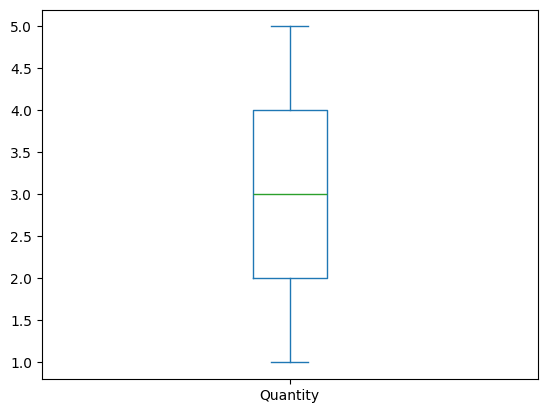

In [43]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity'].plot(kind='box')

<Axes: >

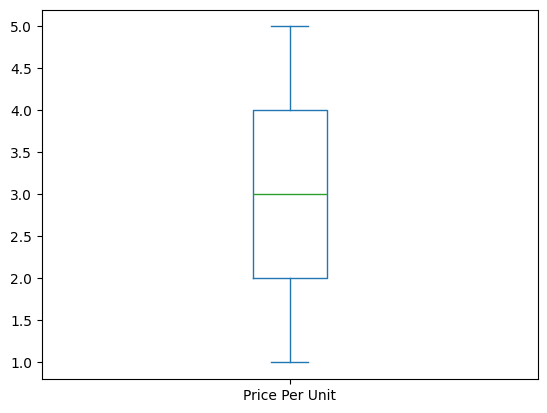

In [44]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Price Per Unit'].plot(kind='box')

In [47]:
# Mengisi data yang hilang dengan mean

df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)
df['Price Per Unit'].fillna(df['Price Per Unit'].mean(), inplace=True)

df[['Quantity', 'Price Per Unit']].isnull().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_22512\1673647181.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)


Quantity          0
Price Per Unit    0
dtype: int64

4. Cleaning Total Spent

In [50]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,2023-06-11


5. Cleaning Payment Method

In [51]:
df['Payment Method'].fillna('Unknown', inplace=True)
df['Payment Method'].isnull().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_22512\1023230475.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment Method'].fillna('Unknown', inplace=True)


np.int64(0)

6. Cleaning Transaction Date

In [ ]:
df = df.dropna(subset=['Transaction Date'])
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

np.int64(0)

In [57]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Transaction Date    0
dtype: int64

In [58]:
df.shape

(8613, 7)

C. Mengecek Nilai Duplikasi

In [59]:
df.duplicated().sum()

np.int64(0)

D. Sorting Data

In [60]:
df = df.sort_values(by='Transaction Date', ascending=True)
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
7306,TXN_6234882,Cookie,4.000000,1.000000,4.000000,Credit Card,2023-01-01
8015,TXN_4801947,Juice,1.000000,3.000000,3.000000,Digital Wallet,2023-01-01
1425,TXN_8842223,Sandwich,5.000000,2.951766,14.758828,Digital Wallet,2023-01-01
768,TXN_5728991,Salad,3.029846,5.000000,15.149228,Unknown,2023-01-01
1806,TXN_2192787,Sandwich,5.000000,4.000000,20.000000,Cash,2023-01-01


E. Grouping dan Aggregasi

In [61]:
grouped_byPayment_method = df.groupby('Payment Method').agg({'Total Spent': 'sum', 'Quantity': 'sum', 'Transaction ID': 'count'}).rename(columns={'Total Spent': 'Total Revenue', 'Quantity': 'Total Items Sold', 'Transaction ID': 'Total Transactions'})

grouped_byPayment_method

,Total Revenue,Total Items Sold,Total Transactions
Payment Method,,,
Cash,17808.563384,5953.447335,1956
Credit Card,17521.583303,5874.626408,1949
Digital Wallet,17680.524671,6023.805481,1980
Unknown,24007.186230,8219.999303,2728


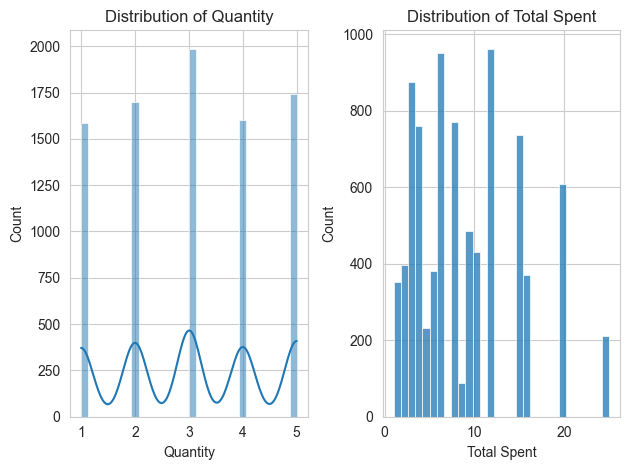

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Quatity
plt.subplot(1, 2, 1)
sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title('Distribution of Quantity')

# Total Spent
plt.subplot(1, 2, 2)
sns.histplot(df['Total Spent'], bins=30)
plt.title('Distribution of Total Spent')

plt.tight_layout()
plt.show()

E. Simpan Dataset

In [64]:
df.to_csv('cleaned_cafe_sales.csv', index=False)